In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt


from tqdm import tqdm
import torch
#from numba import cuda
from helpers.models.DNN import count_parameters
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples
from helpers.flow import sample_from_flow
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [2]:
NUM_COND_INPUTS = 3
NUM_FEATURES = 4

In [ ]:

# -----------------------
# Dataset
# -----------------------
class CaloDataset(Dataset):
    def __init__(self, X):
        self.x = torch.tensor(X[:, :NUM_FEATURES], dtype=torch.float32)
        self.cond = torch.tensor(X[:, NUM_FEATURES:], dtype=torch.float32)

        print(f"Dataset initialized with {len(self.x)} samples, each with {self.x.shape[1]} features and {self.cond.shape[1]} conditions.")

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.cond[idx]


# -----------------------
# Time embedding
# -----------------------
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.exp(
            torch.arange(half_dim, device=device) * -(torch.log(torch.tensor(10000.0)) / (half_dim - 1))
        )
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


# -----------------------
# Conditional MLP
# -----------------------
class DiffusionModel(nn.Module):
    def __init__(self, x_dim=NUM_FEATURES, cond_dim=NUM_COND_INPUTS, time_dim=128, hidden_dim=512):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(),
        )



        self.net = nn.Sequential(
            nn.Linear(x_dim + cond_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim),
        )

    def forward(self, x, t, cond):
        t_emb = self.time_mlp(t)
        x_in = torch.cat([x, cond, t_emb], dim=1)
        return self.net(x_in)


# -----------------------
# Diffusion utilities
# -----------------------
class Diffusion:
    def __init__(self, timesteps=1000, device="cuda"):
        self.timesteps = timesteps
        self.device = device

        beta_start = 1e-4
        beta_end = 0.02
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)

        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

    def sample_timesteps(self, n):
        return torch.randint(0, self.timesteps, (n,), device=self.device)

    def noise_data(self, x, t):
        noise = torch.randn_like(x)
        alpha_hat_t = self.alpha_hat[t][:, None]
        x_t = torch.sqrt(alpha_hat_t) * x + torch.sqrt(1 - alpha_hat_t) * noise
        return x_t, noise


# -----------------------
# Training loop
# -----------------------
from tqdm import tqdm

def train(model, diffusion, dataloader, epochs=1, lr=1e-3, device="cuda"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    all_losses = []
    model.train()

    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")

    for epoch in epoch_bar:
        total_loss = 0

        for x, cond in dataloader:
            x = x.to(device)
            cond = cond.to(device)

            t = diffusion.sample_timesteps(x.shape[0])
            x_t, noise = diffusion.noise_data(x, t)

            t = t.float() / diffusion.timesteps

            pred_noise = model(x_t, t, cond)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        all_losses.append(avg_loss)

        # Update tqdm nicely
        epoch_bar.set_postfix(loss=f"{avg_loss:.6f}")

    plt.figure(figsize=(10, 5))
    plt.plot(all_losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Over Epochs")
    plt.legend()
    plt.show()

In [4]:
@torch.no_grad()
def sample_with_dataset_conditions(model, diffusion, cond, device="cuda"):
    """
    cond: (N, NUM_COND_INPUTS) tensor directly from dataset (side, layer)
    returns: generated x (N, NUM_FEATURES)
    """

    model.eval()
    cond = cond.to(device)
    n_samples = cond.shape[0]

    # Start from noise
    x = torch.randn((n_samples, NUM_FEATURES), device=device)

    for t in tqdm(reversed(range(diffusion.timesteps)), desc="Sampling", total=diffusion.timesteps):
        t_tensor = torch.full((n_samples,), t, device=device).float()
        t_norm = t_tensor / diffusion.timesteps

        pred_noise = model(x, t_norm, cond)

        alpha = diffusion.alphas[t]
        alpha_hat = diffusion.alpha_hat[t]
        beta = diffusion.betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
            * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * pred_noise)
            + torch.sqrt(beta) * noise
        )

    return x

In [5]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_BDTS = 10

collections = [
#    "InnerTrackerBarrelCollection",
  # "InnerTrackerEndcapCollection",
 #   "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
 #   "VertexBarrelCollection",   
#  "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,5,6]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z": 4
    
    ,
    "side":5,
    "layer":6
}

feature_order_barrel =[0, 4, 2, 3, 1,  5, 6]
feature_indices_dict_barrel = {
    "r":4,
    "phi": 2,
    "z":3,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}

SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []


col_name = "OuterTrackerEndcapCollection"

log_vars = []

# %%
FEATURE_ORDER = feature_order_dict[col_name]
FEATURES = "rphi"
WORKING_DIR = "/pscratch/sd/r/rmastand/muon_collider"
TRAINING_FRAC = 1
NUM_COND_INPUTS = 2
BIN_BOUND = 8
NUM_BINS = 60

save_dir = "."
ZUKO_ID = "."


In [6]:

X, feature_labels = load_in_data([col_name], FEATURES, WORKING_DIR, TRAINING_FRAC, NUM_COND_INPUTS, feature_order=FEATURE_ORDER)
print(f"Data has shape {X.shape}")
print("Feature labels:", feature_labels)


Data has shape (1465825, 7)
Feature labels: ['log($E$) [Gev]', '$t$', '$r$', '$\\phi$', '$z$', 'side (cond)', 'layer (cond)']


In [7]:


bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(X.shape[1])}

for i in range(X.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(X[:,i])), np.log10(1.1*np.max(X[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(X[:,i] - 1), np.max(X[:,i] + 1), NUM_BINS) 


fig_samp, axes_samp = plot_corner_hist_2d(
        X,
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "data",
    )
plt.savefig(f"{save_dir}/data_final")
plt.close()

# %%


X_preproc = preprocess_data(X, save_dir, ZUKO_ID, NUM_COND_INPUTS)





print(X_preproc[:,:NUM_FEATURES].shape, X_preproc[:, NUM_FEATURES:].shape)



(1465825, 4) (1465825, 3)


In [8]:
print(NUM_FEATURES)

4


Dataset initialized with 1465825 samples, each with 4 features and 3 conditions.
Model has 350,852 parameters


Training: 100%|██████████| 20/20 [03:11<00:00,  9.58s/epoch, loss=0.231469]


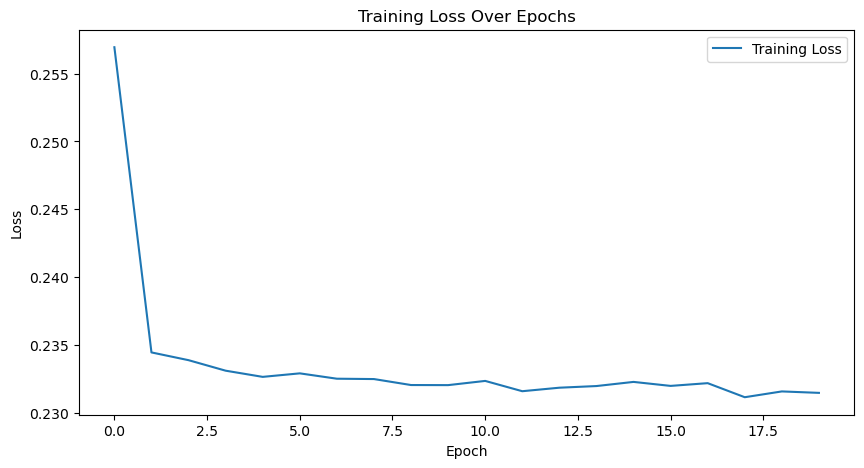

In [9]:
dataset = CaloDataset(X_preproc)
dataloader = DataLoader(dataset, batch_size=2048, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = DiffusionModel().to(device)
print(f"Model has {count_parameters(model):,} parameters")
diffusion = Diffusion(device=device)

train(model, diffusion, dataloader, epochs=20)

In [10]:
cond = torch.tensor(X_preproc[:, NUM_FEATURES:], dtype=torch.float32)

samples = sample_with_dataset_conditions(
    model,
    diffusion,
    cond,
    device=device
)

Sampling: 100%|██████████| 1000/1000 [01:22<00:00, 12.18it/s]


In [11]:
X_flow = np.concatenate([samples.detach().cpu().numpy(), X_preproc[:, NUM_FEATURES:]], axis = 1)
print(X_flow.shape)

(1465825, 7)


(<Figure size 4200x700 with 7 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$t$'>, <Axes: xlabel='$r$'>,
        <Axes: xlabel='$\\phi$'>, <Axes: xlabel='$z$'>,
        <Axes: xlabel='side (cond)'>, <Axes: xlabel='layer (cond)'>],
       dtype=object))

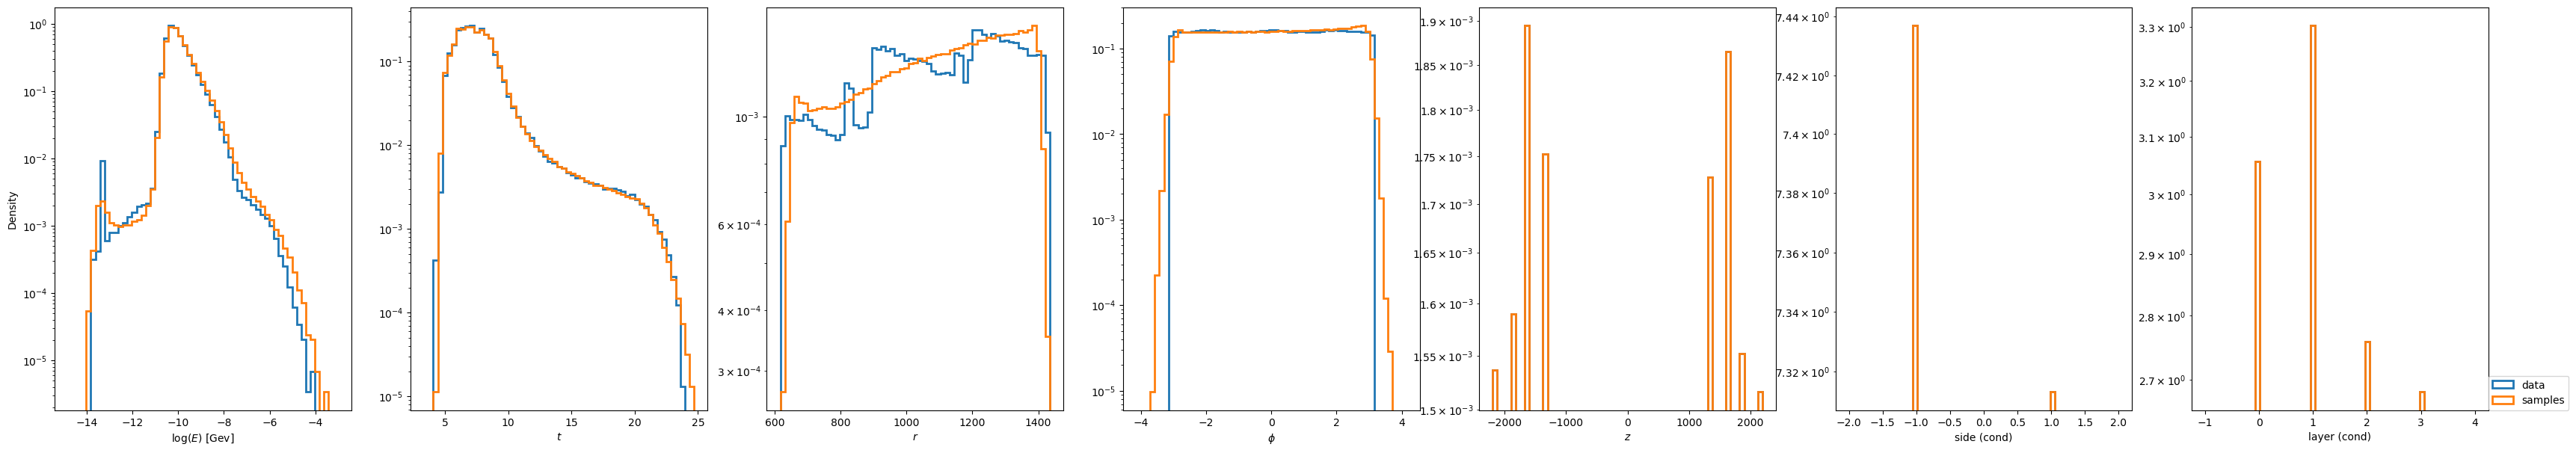

In [12]:
# inverse preprocess

all_data_dir = {col_name: inverse_preprocess_data(X_preproc, save_dir, ZUKO_ID, NUM_COND_INPUTS)}
all_samples_dir = {col_name: inverse_preprocess_data(X_flow, save_dir, ZUKO_ID, NUM_COND_INPUTS) }
log_vars = []


plot_hists_1d({"data":all_data_dir[col_name], "samples":all_samples_dir[col_name] }, bins_dict, log_dims=[], labels = feature_labels)


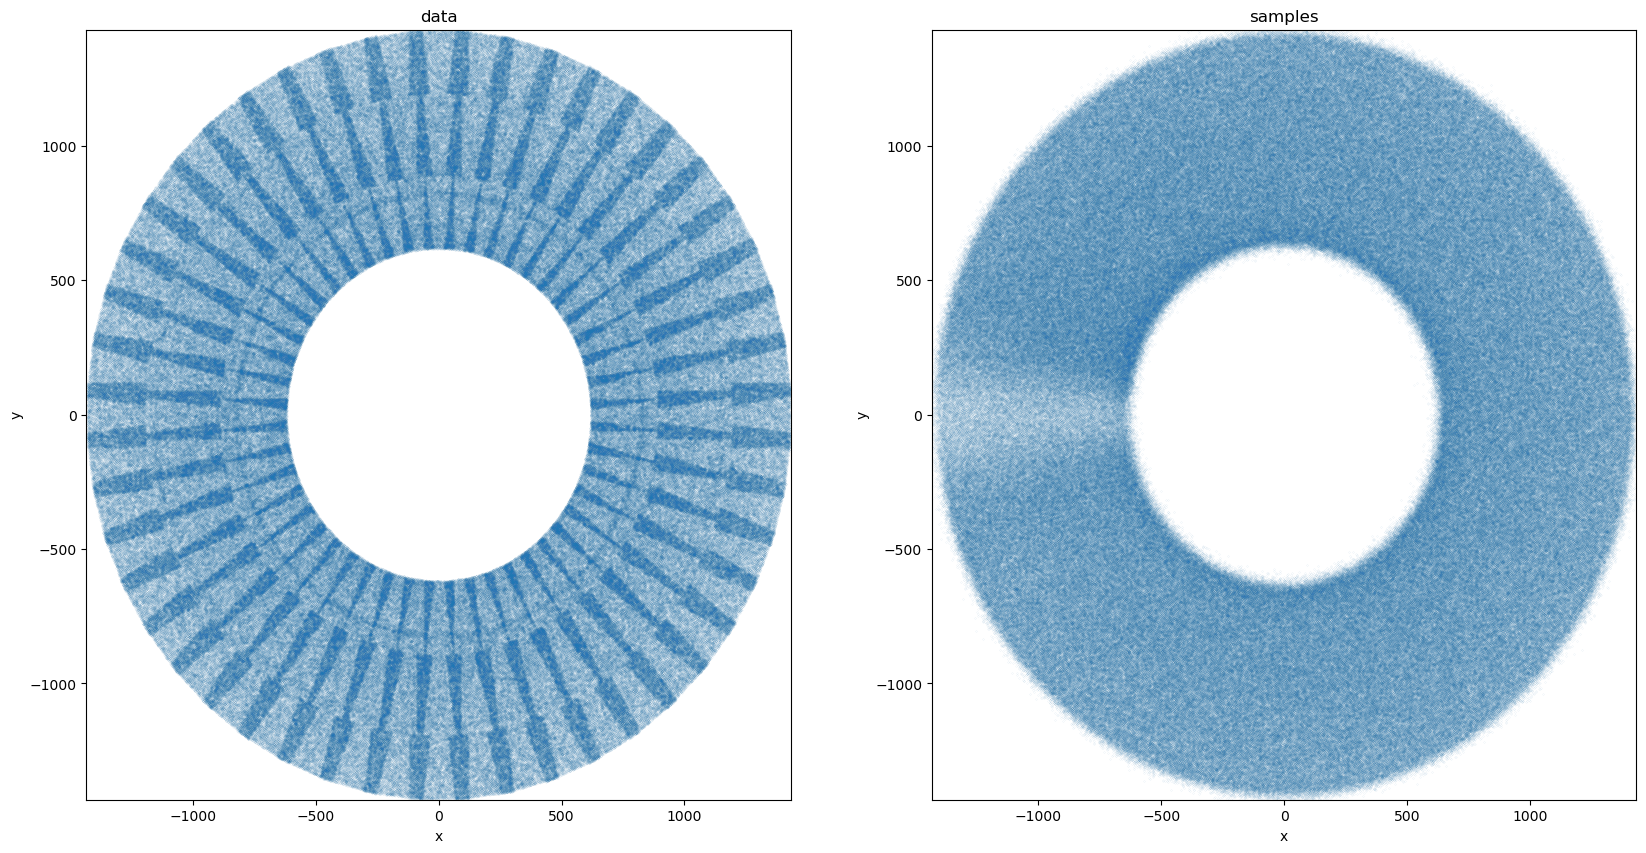

In [13]:

def make_2d_plots(data_array, labels):


    fig, ax = plt.subplots(1, len(data_array), figsize = (10*len(data_array), 10))

    

    for i, key in enumerate(data_array.keys()):

        coord0_lim = np.min(data_array["data"][0]), np.max(data_array["data"][0])
        coord1_lim = np.min(data_array["data"][1]), np.max(data_array["data"][1])
            
        ax[i].scatter(data_array[key][0], data_array[key][1], s = 0.001)
        ax[i].set_xlim(coord0_lim)
        ax[i].set_ylim(coord1_lim)
        ax[i].set_xlabel(labels[0])
        ax[i].set_ylabel(labels[1])
        ax[i].set_title(key)

    plt.show()



    
loc_array = {
    "data": (
        all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
        np.cos(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
        all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
        np.sin(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
    ),
    "samples": (
        all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
        np.cos(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
        all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
        np.sin(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
    ),

}

make_2d_plots(loc_array, ["x", "y"])



Using device: cuda
Analyzing OuterTrackerEndcapCollection...
(1465825, 7) (1465825, 7)
Len data: 100000
Len samples unmasked: 100000

Per-feature BDT performance:
Feature 0 BDT AUC: 0.5173 ± 0.0000
Feature 1 BDT AUC: 0.5147 ± 0.0000
Feature 2 BDT AUC: 0.5297 ± 0.0000
Feature 3 BDT AUC: 0.5729 ± 0.0000
Feature 4 BDT AUC: 0.5038 ± 0.0000
Feature 5 BDT AUC: 0.5018 ± 0.0000
Feature 6 BDT AUC: 0.5033 ± 0.0000
auc 0.5981938808 \pm 0.0. best epoch [578] of 1000.



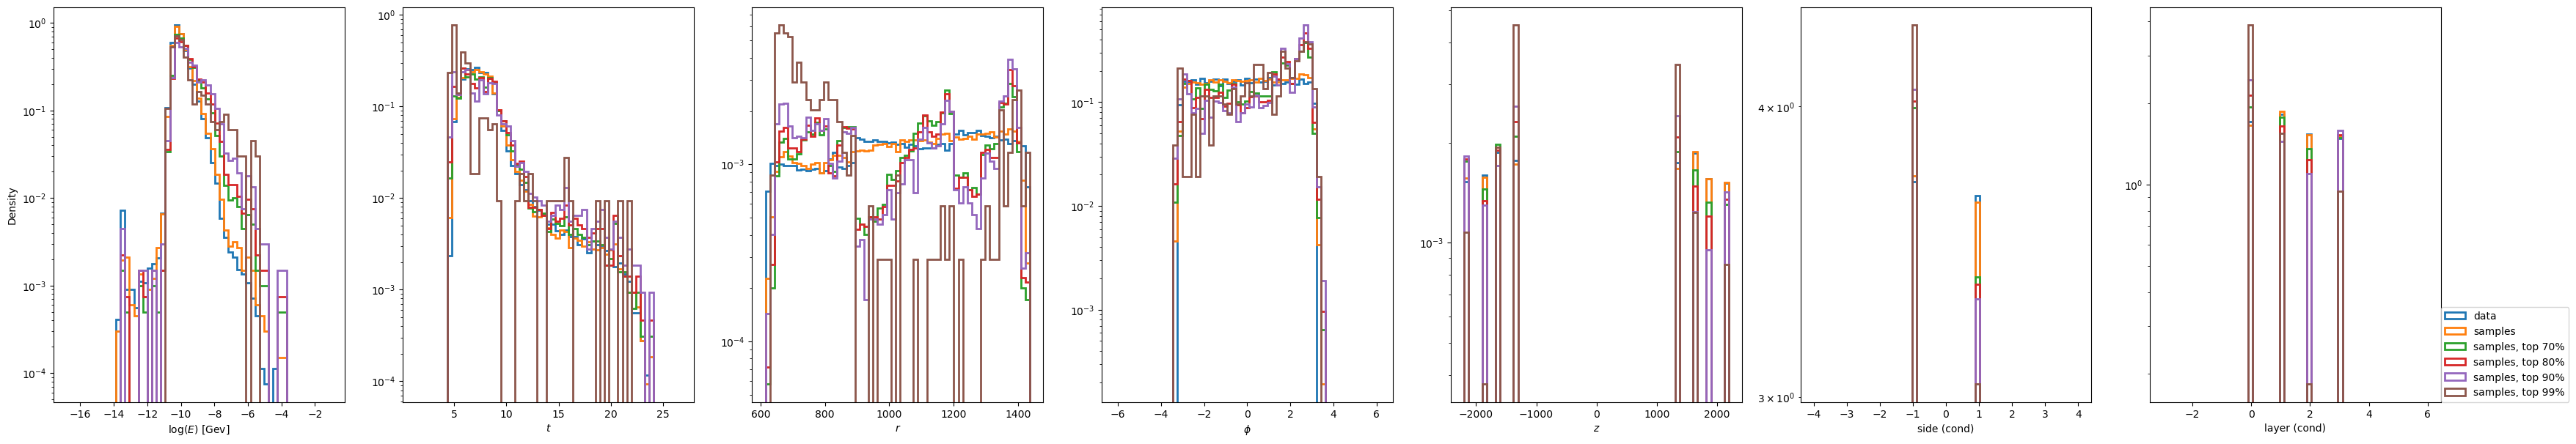

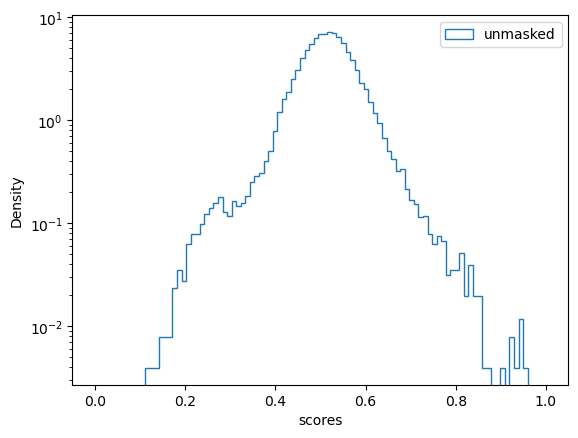

In [14]:
from helpers.evaluation import run_eval_suite_BDTs, run_eval_suite_R
log_vars = []
bins_dict[col_name] = {}

single_bdt_results, all_scores, all_plot = {}, {}, {}

import torch
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
num_BDTs = 1
N = 100_000

for col_name in [col_name]:

    print(f"Analyzing {col_name}...")
    

     
    for i in range(X_preproc.shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 
    
    indices_1 = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    indices_2 = np.random.choice(all_samples_dir[col_name].shape[0], size=N, replace=False)
    

    print(all_data_dir[col_name].shape, all_samples_dir[col_name].shape)


    tmp = run_eval_suite_BDTs(all_data_dir[col_name][indices_1], 
                              {"unmasked":all_samples_dir[col_name][indices_2], 
                             },
                                bins_dict[col_name],
                                device=device,
                                num_BDTs=num_BDTs,
                                plot_suffix=f"_{col_name}",
                                log_vars=log_vars,
                                feature_labels=feature_labels,
                                )

    single_bdt_results[col_name] = tmp[0]
    all_scores[col_name] = tmp[1]
    all_plot[col_name] = tmp[2]


  #  run_eval_suite_R(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, [0.1, 0.2, 0.4],  100, plot_suffix="")
#
    
